## Developing the Winning Model 

In [1]:
import numpy as np
import pandas as pd
#%pip install yfinance
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import zipfile
import requests
warnings.filterwarnings("ignore")


In [2]:
# Load the data from the zip file

## PATH NEEDS TO BE UPDATED TO GITHUB DATA PATH
zip_path2 = "/Users/christoomey/Desktop/Courses/ADAN8888_Applied_Analytics_Project/Data/final_dataset_20260224v2.csv.zip"
with zipfile.ZipFile(zip_path2) as z:
    df = pd.read_csv(z.open("final_dataset_20260224v2.csv"))

## ## ## ## 

tickers = df["Ticker"].unique()
print(f"Unique tickers in final dataset: {len(tickers)}")
print("Size of dataset:",
"Rows:",df.shape[0],
"Columns:",df.shape[1])

Unique tickers in final dataset: 1993
Size of dataset: Rows: 302024 Columns: 18


In [3]:
# count number of positive fwd_excess_return
print("Number of positive fwd_excess_return:", (df["fwd_excess"] > 0).sum())
print("Number of negative fwd_excess_return:", (df["fwd_excess"] < 0).sum())
print("Number of zero fwd_excess_return:", (df["fwd_excess"] == 0).sum())

df = df.copy()

df['y'] = (df['fwd_excess'] > 0).astype(int)



Number of positive fwd_excess_return: 143948
Number of negative fwd_excess_return: 151730
Number of zero fwd_excess_return: 287


In [4]:
# Ensure datetime
df['Date'] = pd.to_datetime(df['Date'])

# Find latest month in dataset
max_date = df['Date'].max()

# Compute cutoff
cutoff_date = max_date - pd.DateOffset(months=2)

# Subset
df_last3 = df[df['Date'] > cutoff_date].copy()
df_last3.head()


,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y
296052,2025-12-31,NVDA,0.4632,-0.1615,-0.0187,-0.0007,-0.0109,-0.1615,-0.0187,-0.0007,-0.0587,-0.1146,0.0987,0.3188,0.2869,186.5000,NaN,NaN,0
296053,2025-12-31,GOOGL,-0.2588,0.9727,0.2777,0.0626,0.1162,0.9727,0.2777,0.0626,-0.2683,-0.1787,0.6149,0.7311,1.4220,313.0000,NaN,NaN,0
296054,2025-12-31,AAPL,-0.2902,0.1099,0.0543,-0.0705,-0.0779,0.1099,0.0543,-0.0705,-0.6517,-0.2838,0.5852,0.7074,0.3279,271.6058,NaN,NaN,0
296055,2025-12-31,MSFT,-0.2136,-0.4135,-0.1202,-0.0553,-0.0587,-0.4135,-0.1202,-0.0553,-0.6087,-0.3388,-0.0043,0.2366,-0.3248,482.5187,NaN,NaN,0
296056,2025-12-31,AMZN,-0.1489,0.0413,-0.0823,-0.0795,-0.0966,0.0413,-0.0823,-0.0795,-0.1768,-0.1408,0.3160,0.4923,-0.1244,230.8200,NaN,NaN,0


### Split the Data 70/15/15

In [5]:
def time_split(df, date_col='Date', train_frac=0.7, val_frac=0.15):
    df = df.sort_values(date_col).copy()
    unique_dates = df[date_col].drop_duplicates().sort_values().to_numpy()

    # retreive the num of rows to create train/val/test split
    n = len(unique_dates)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))

    train_dates = unique_dates[:train_end]
    val_dates   = unique_dates[train_end:val_end]
    test_dates  = unique_dates[val_end:]

    train = df[df[date_col].isin(train_dates)]
    val   = df[df[date_col].isin(val_dates)]
    test  = df[df[date_col].isin(test_dates)]

    return train, val, test

training_data, validation_data, testing_data = time_split(df)
print("Train size:", training_data.shape)
print("Val size:", validation_data.shape)
print("Test size:", testing_data.shape)
training_data.tail()

Train size: (193638, 19)
Val size: (52704, 19)
Test size: (55682, 19)


,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y
192479,2021-04-30,SSNC,0.2723,0.1806,-0.0387,-0.1580,-0.1615,0.1806,-0.0387,-0.1580,-0.5679,-0.0456,0.5045,0.5021,-0.3760,69.7704,0.0042,0.0585,1
192485,2021-04-30,LH,0.0402,0.0731,-0.0345,-0.0866,-0.0872,0.0731,-0.0345,-0.0866,-0.5906,-0.0432,0.5045,0.5021,0.2354,218.1971,0.0596,0.1139,1
192486,2021-04-30,IHG,-0.0824,0.0408,-0.0311,-0.1020,-0.0977,0.0408,-0.0311,-0.1020,-0.3594,-0.0339,0.5045,0.5021,-0.2273,65.4198,-0.1253,-0.0710,0
192487,2021-04-30,CHD,-0.6758,-0.6346,-0.0551,-0.1904,-0.1656,-0.6346,-0.0551,-0.1904,-0.7487,-0.0506,0.2809,-0.5392,-1.1342,80.8025,-0.0415,0.0127,0
192484,2021-04-30,NVR,0.3069,-0.0899,-0.0381,-0.0860,-0.0957,-0.0899,-0.0381,-0.0860,-0.4088,-0.0409,0.5045,0.5021,-0.1548,5018.1001,-0.0135,0.0408,0


### Preprocess the Data 

In [6]:
def preprocess_data(df):

    # preprocess the data by dropping rows with missing values
    print("Missing fwd_excess values:")

    df_dropped = df.dropna()
    print("---  ---  ---")
    print("Length of original:",len(df.index))
    print("Length of dropped:",len(df_dropped.index))
    print("Sanity check - missing fwd_excess values after dropping:")
    print(df_dropped[["Date","Ticker","fwd_excess"]].tail(5)) 

   
    
    # Create log_adj_close column
    df_dropped["log_adj_close"] = np.log(df_dropped["adj_close"])
    df_dropped[["adj_close","log_adj_close"]].hist(figsize=(14, 10), bins=50)
    plt.tight_layout()
    plt.show()
    
    return df_dropped

Missing fwd_excess values:
---  ---  ---
Length of original: 193638
Length of dropped: 175057
Sanity check - missing fwd_excess values after dropping:
             Date Ticker  fwd_excess
192479 2021-04-30   SSNC      0.0042
192485 2021-04-30     LH      0.0596
192486 2021-04-30    IHG     -0.1253
192487 2021-04-30    CHD     -0.0415
192484 2021-04-30    NVR     -0.0135


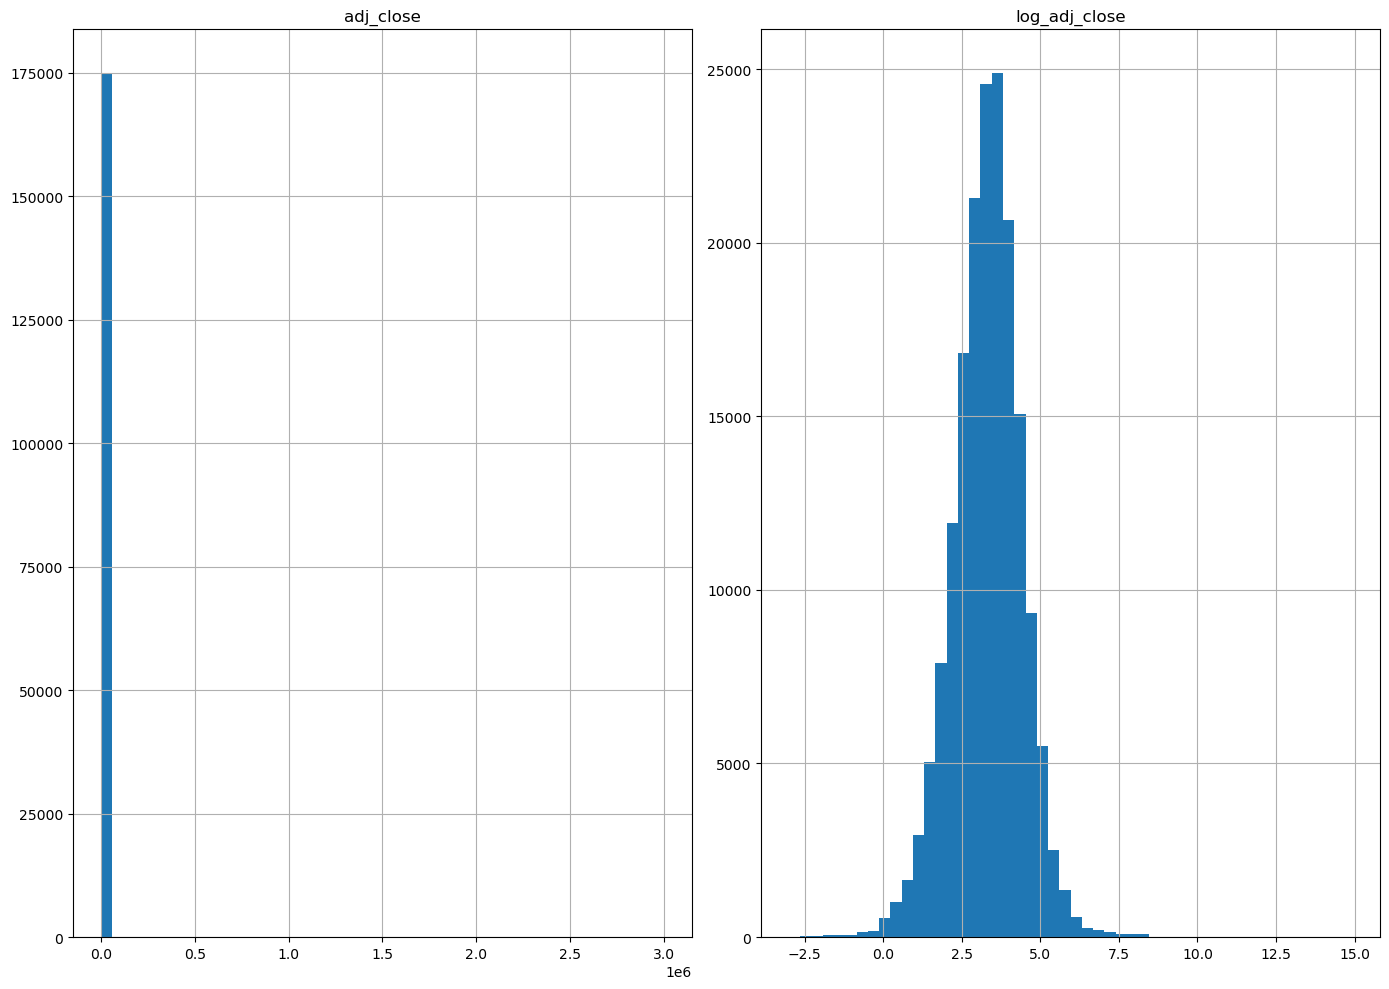

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y,log_adj_close
14213,2011-01-31,TTMI,0.4972,2.4448,1.1222,0.4989,0.3268,2.4448,1.1222,0.4989,1.9380,1.5628,0.5788,0.5941,1.7258,15.9000,0.1377,0.2025,1,2.766319
14216,2011-01-31,DSGX,-0.2733,-0.0527,-0.1622,-0.4035,-0.3472,-0.0527,-0.1622,-0.4035,-0.1112,-0.1488,0.4071,0.4935,-0.0843,6.9700,-0.1136,-0.0488,0,1.941615
14215,2011-01-31,CHDN,-0.6391,0.2684,-0.2432,-0.4573,-0.2885,0.2684,-0.2432,-0.4573,-0.2997,-0.2583,-0.2127,0.1302,-0.0399,6.2609,-0.0576,0.0072,0,1.834324
14214,2011-01-31,GSAT,-0.9448,-1.6521,-1.5770,0.1845,0.5515,-1.6521,-1.5770,0.1845,0.8672,1.1957,-3.3892,-2.4986,-1.9339,20.1000,-0.1021,-0.0373,0,3.000720
14218,2011-01-31,MASI,0.1469,-0.5690,0.3651,-0.3740,-0.4427,-0.5690,0.3651,-0.3740,0.1033,-0.0491,0.4829,0.5379,0.1353,28.5698,0.0956,0.1604,1,3.352350


In [7]:
train_df = preprocess_data(training_data)
train_df.head(5)

Missing fwd_excess values:
---  ---  ---
Length of original: 55682
Length of dropped: 48493
Sanity check - missing fwd_excess values after dropping:
             Date Ticker  fwd_excess
294730 2025-11-30    GPN      0.0285
294731 2025-11-30   BURL      0.2126
294732 2025-11-30   KTOS      0.1828
294733 2025-11-30   TRMB     -0.1891
294728 2025-11-30   SBAC      0.0290


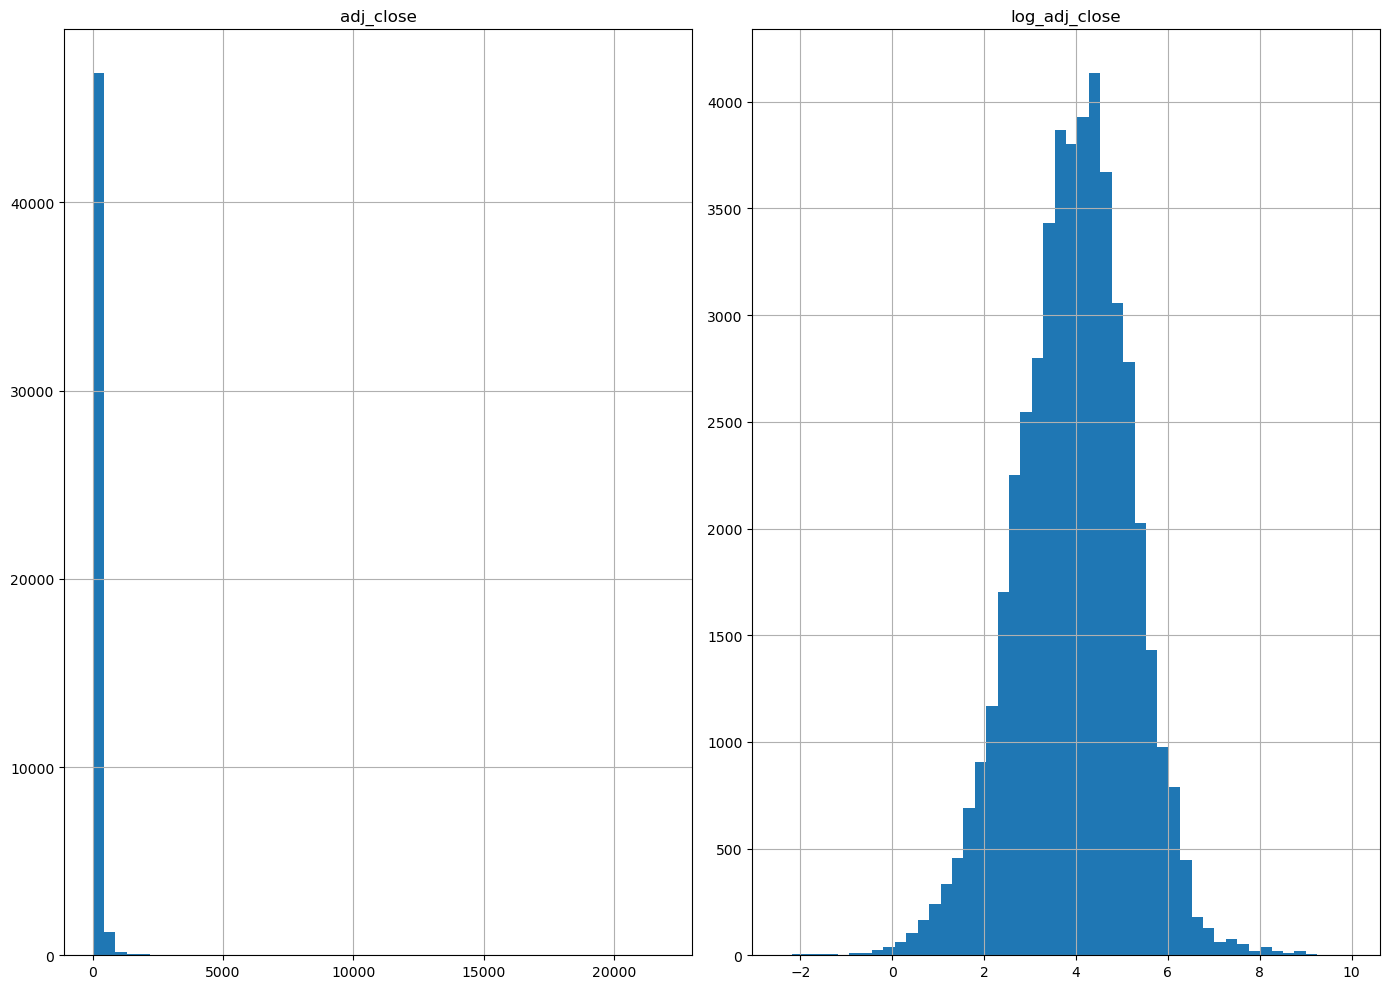

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y,log_adj_close
247583,2023-10-31,MNSO,0.2820,1.8365,1.5085,10.5307,10.4558,1.8365,1.5085,10.5307,0.8386,0.7170,1.0479,1.1475,2.2729,24.0159,-0.4893,-0.3299,0,3.178716
247584,2023-10-31,ACT,0.6388,0.7340,0.6076,0.1936,0.0074,0.7340,0.6076,0.1936,-0.5861,-0.4127,0.9323,1.0483,0.8457,25.5351,-0.0930,0.0664,0,3.240054
247585,2023-10-31,ZETA,-0.1585,-0.1970,-0.7219,-0.3790,-0.3453,-0.1970,-0.7219,-0.3790,0.8372,0.4462,0.0756,-0.4865,-0.4454,7.8000,0.0817,0.2410,1,2.054124
247586,2023-10-31,RHP,0.7997,0.1445,-0.0652,-0.2143,-0.4258,0.1445,-0.0652,-0.2143,-0.3047,-0.3832,0.5455,0.7163,0.1875,77.3804,0.1373,0.2966,1,4.348734
247592,2023-10-31,ARW,-0.4508,-0.4682,-0.0130,0.1119,0.2669,-0.4682,-0.0130,0.1119,-0.2618,-0.3952,-0.3258,-0.0314,-0.2352,113.4100,-0.1793,-0.0199,0,4.731010


In [8]:
test_df = preprocess_data(testing_data)
test_df.head(5)

Missing fwd_excess values:
---  ---  ---
Length of original: 52704
Length of dropped: 50961
Sanity check - missing fwd_excess values after dropping:
             Date Ticker  fwd_excess
245100 2023-09-30    HPQ      0.0652
245099 2023-09-30    PFG     -0.0149
245098 2023-09-30   TWLO      0.1799
245097 2023-09-30   CHRW     -0.1058
245108 2023-09-30    RCI      0.1129


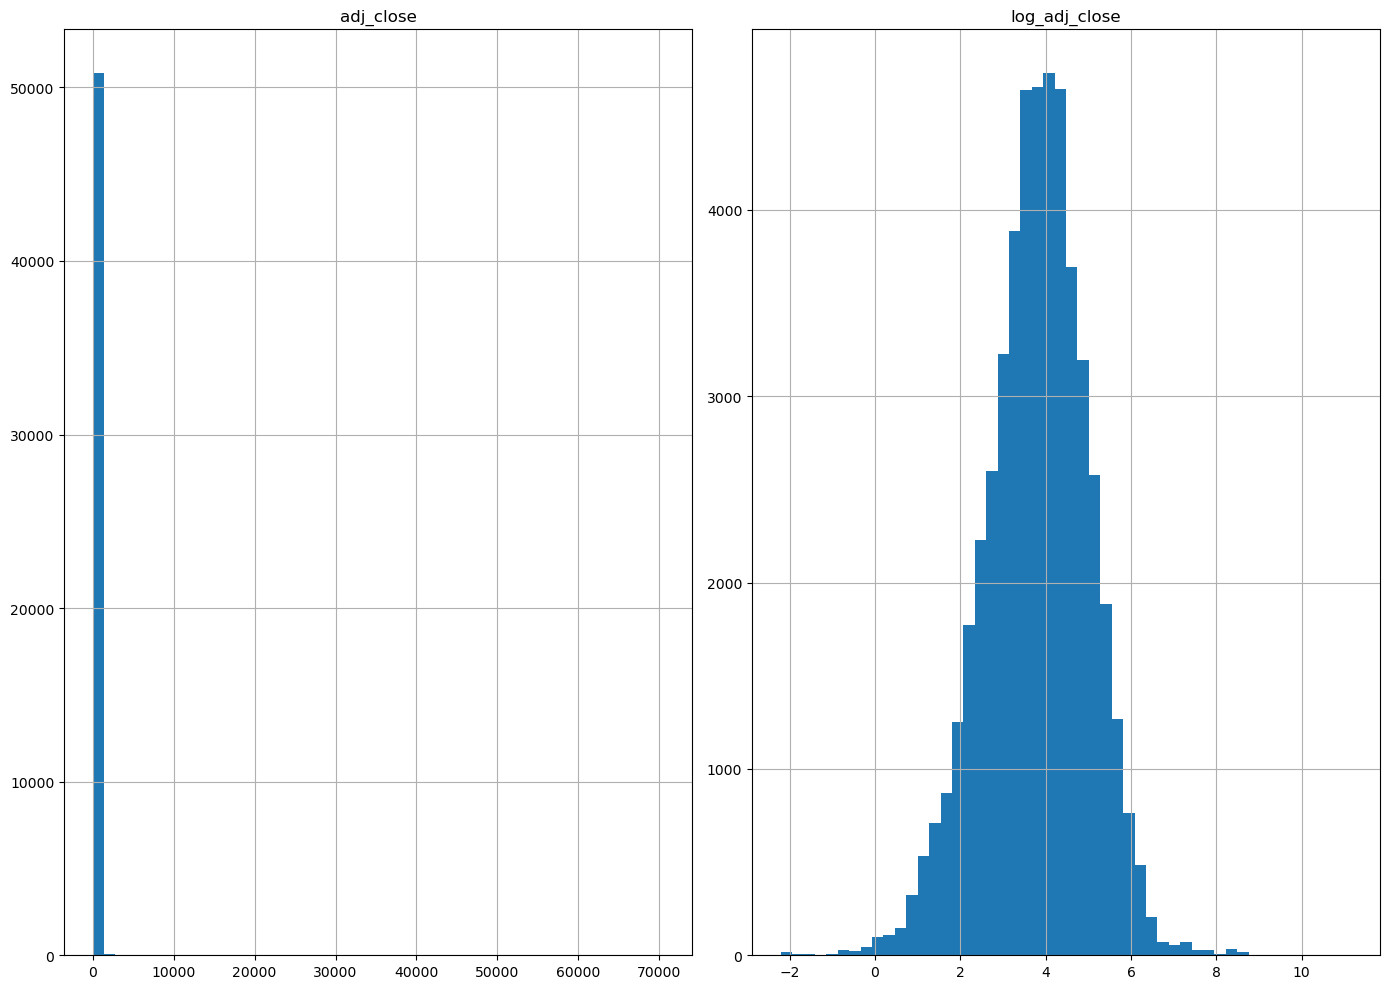

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,vol_3m,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y,log_adj_close
194796,2021-05-31,SITE,-0.6464,-0.0770,-0.0860,-0.0469,-0.0277,-0.0770,-0.0860,-0.0469,0.2931,0.1085,0.1177,0.1482,-0.2446,172.0400,0.0845,0.1631,1,5.147727
194804,2021-05-31,DLB,-0.6009,-0.5411,-0.3627,-0.0460,-0.0284,-0.5411,-0.3627,-0.0460,-0.5613,-0.5965,0.1629,0.1910,-0.3061,90.8153,-0.0602,0.0184,0,4.508828
194803,2021-05-31,M,0.8177,0.5672,1.0082,0.2009,0.1754,0.5672,1.0082,0.2009,1.2113,1.2406,0.5328,0.5413,1.7165,15.3682,0.1463,0.2248,1,2.732300
194805,2021-05-31,TRNO,-0.3711,0.2303,-0.3603,-0.1159,-0.1162,0.2303,-0.3603,-0.1159,-0.6730,-0.6928,0.3913,0.4073,-0.4687,55.7725,-0.0238,0.0548,0,4.021281
194802,2021-05-31,DAR,-0.3743,-0.0735,0.2600,0.2133,0.2577,-0.0735,0.2600,0.2133,0.4512,0.3094,-0.1731,-0.1272,0.1532,68.4600,0.0097,0.0882,1,4.226250


In [9]:
val_df = preprocess_data(validation_data)
val_df.head(5)

### Create the Train, Validation, and Test sets

In [10]:
feature_cols = [col for col in train_df.columns if col not in ["Date", "Ticker", "fwd_excess", "fwd_return", "y"]]

X_train, y_train = train_df[feature_cols], train_df['y']
X_val, y_val     = val_df[feature_cols],   val_df['y']
X_test, y_test   = test_df[feature_cols],  test_df['y']

### Logistic Regression Models

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# L1 (Lasso) Logistic Regression

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(
        penalty='l1',
        solver='saga',
        max_iter=1000
    ))
])

log_reg.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logit',
                 LogisticRegression(max_iter=1000, penalty='l1',
                                    solver='saga'))])

In [12]:
# Elastic Net Logistic Regression 

elastic_net = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,   # 50% L1 / 50% L2
        max_iter=1000
    ))
])

elastic_net.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logit',
                 LogisticRegression(l1_ratio=0.5, max_iter=1000,
                                    penalty='elasticnet', solver='saga'))])

In [13]:
# Weighted Logistic Regression

weight_log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(
        class_weight='balanced',
        max_iter=500
    ))
])

weight_log_reg.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logit',
                 LogisticRegression(class_weight='balanced', max_iter=500))])

### Light Gradient Boosting Machine (LightGBM) Models

In [14]:
# LightGBM Model 1 with more conservative hyperparameters

import lightgbm as lgb

lgb_model1 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=6,
    num_leaves=31
)

lgb_model1.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],

)

[LightGBM] [Info] Number of positive: 86255, number of negative: 88802
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001931 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 175057, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.492725 -> initscore=-0.029101
[LightGBM] [Info] Start training from score -0.029101


LGBMClassifier(learning_rate=0.01, max_depth=6, n_estimators=1000)

In [15]:
# LightGBM Model 2 with more aggressive hyperparameters

lgb_model2 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=12,
    num_leaves=31,
    class_weight="balanced",    
)

lgb_model2.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],

)

[LightGBM] [Info] Number of positive: 86255, number of negative: 88802
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010760 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 175057, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.01, max_depth=12,
               n_estimators=1000)

In [16]:
# LightGBM Model 3 with even more aggressive hyperparameters

lgb_model3 = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.01, 
    max_depth=6,
    num_leaves=20
)

lgb_model3.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],

)

[LightGBM] [Info] Number of positive: 86255, number of negative: 88802
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005504 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 175057, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.492725 -> initscore=-0.029101
[LightGBM] [Info] Start training from score -0.029101


LGBMClassifier(learning_rate=0.01, max_depth=6, n_estimators=500, num_leaves=20)

### Neural Network Models

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.random.set_seed(SEED)

In [18]:
'''
X_train, y_train = train_df[feature_cols], train_df['y']
X_val, y_val     = val_df[feature_cols],   val_df['y']
X_test, y_test   = test_df[feature_cols],  test_df['y']
'''
X_train_nn = X_train.values
y_train_nn = y_train.values
X_val_nn = X_val.values
y_val_nn = y_val.values
X_test_nn = X_test.values
y_test_nn = y_test.values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_nn)
X_val_s = scaler.transform(X_val_nn)
X_test_s = scaler.transform(X_test_nn)

In [19]:
# Class weights for imbalance
classes = np.unique(y_train_nn)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_nn)
class_weight = dict(zip(classes, weights))
class_weight

{0: 0.9856591067768744, 1: 1.0147643614862907}

In [20]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

In [21]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model(model, X, y, name="Model"):
    prob = model.predict(X, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)

    print(f"\n{name}")
    print("Accuracy:", round(accuracy_score(y, pred), 4))
    print("F1:", round(f1_score(y_test, pred, average='macro'), 4))
    print("ROC AUC:", round(roc_auc_score(y, prob), 4))
    print("\nConfusion Matrix")
    print(confusion_matrix(y, pred))
    print("\nClassification Report")
    print(classification_report(y, pred, digits=4))


In [22]:
def build_mlp_baseline(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc")
        ]
    )
    return model

model_base = build_mlp_baseline(X_train_s.shape[1])

history_base = model_base.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)



Epoch 1/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5065 - auc: 0.5088 - loss: 0.6949 - val_accuracy: 0.4938 - val_auc: 0.5015 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 2/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5133 - auc: 0.5212 - loss: 0.6922 - val_accuracy: 0.4907 - val_auc: 0.5000 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 3/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5135 - auc: 0.5219 - loss: 0.6920 - val_accuracy: 0.4938 - val_auc: 0.5025 - val_loss: 0.6942 - learning_rate: 0.0010
Epoch 4/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step - accuracy: 0.5163 - auc: 0.5265 - loss: 0.6916 - val_accuracy: 0.4952 - val_auc: 0.5008 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 5/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 999us/step - accuracy: 0.5175 - auc: 0.5284 - loss: 0.6913 - val_accuracy: 0.4934 - val_auc: 0.5010 - val_loss: 0.6949 - learning_rate: 0.0010
Epoch 6/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5201

In [23]:
def build_mlp_regularized(input_dim):
    l2 = regularizers.l2(1e-4)

    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(256, kernel_regularizer=l2)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Dense(128, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(64, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.20)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc")
        ]
    )
    return model

model_reg = build_mlp_regularized(X_train_s.shape[1])

history_reg = model_reg.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)




Epoch 1/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5062 - auc: 0.5084 - loss: 0.7410 - val_accuracy: 0.4916 - val_auc: 0.4926 - val_loss: 0.7228 - learning_rate: 5.0000e-04
Epoch 2/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5075 - auc: 0.5106 - loss: 0.7226 - val_accuracy: 0.4904 - val_auc: 0.4925 - val_loss: 0.7188 - learning_rate: 5.0000e-04
Epoch 3/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5109 - auc: 0.5168 - loss: 0.7159 - val_accuracy: 0.4931 - val_auc: 0.4983 - val_loss: 0.7146 - learning_rate: 5.0000e-04
Epoch 4/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5132 - auc: 0.5201 - loss: 0.7114 - val_accuracy: 0.4966 - val_auc: 0.4994 - val_loss: 0.7111 - learning_rate: 5.0000e-04
Epoch 5/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5176 - auc: 0.5264 - loss: 0.7078 - val_accuracy: 0.4963 - val_auc: 0.5004 - val_loss: 0.7092 - learning_rate: 2.5000e-04
Epoch 6/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - 

In [24]:
def build_mlp_regularized_deep(input_dim):
    l2 = regularizers.l2(1e-4)

    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(256, kernel_regularizer=l2)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Dense(128, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(64, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.10)(x)

    x = layers.Dense(32, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.05)(x)

    x = layers.Dense(16, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc")
        ]
    )
    return model

model_reg_deep = build_mlp_regularized_deep(X_train_s.shape[1])

history_reg_deep = model_reg_deep.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)



Epoch 1/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5055 - auc: 0.5063 - loss: 0.7364 - val_accuracy: 0.4889 - val_auc: 0.4928 - val_loss: 0.7286 - learning_rate: 5.0000e-04
Epoch 2/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5086 - auc: 0.5128 - loss: 0.7242 - val_accuracy: 0.4880 - val_auc: 0.4939 - val_loss: 0.7244 - learning_rate: 5.0000e-04
Epoch 3/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5119 - auc: 0.5186 - loss: 0.7193 - val_accuracy: 0.4867 - val_auc: 0.4912 - val_loss: 0.7202 - learning_rate: 5.0000e-04
Epoch 4/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5129 - auc: 0.5209 - loss: 0.7145 - val_accuracy: 0.4837 - val_auc: 0.4914 - val_loss: 0.7152 - learning_rate: 5.0000e-04
Epoch 5/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5165 - auc: 0.5252 - loss: 0.7106 - val_accuracy: 0.4838 - val_auc: 0.4950 - val_loss: 0.7125 - learning_rate: 2.5000e-04
Epoch 6/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - 

In [25]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score

## Used to Evaluate NN models ##
def evaluate_nn_model(model, X, y, name="Model"):
    prob = model.predict(X, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)

    print(f"\n{name}")
    print("Accuracy:", round(accuracy_score(y, pred), 4))
    print("F1:", round(f1_score(y, pred, average='macro'), 4))
    print("ROC AUC:", round(roc_auc_score(y, prob), 4))
    print("\nConfusion Matrix")
    print(confusion_matrix(y, pred))
    print("\nClassification Report")
    print(classification_report(y, pred, digits=4))


## Used to Evaluate the Logistic Regression and LightGBM models ##
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    print("Classification Report:\n")
    print(classification_report(y_test, y_pred))
    print("F1:", round(f1_score(y_test, y_pred, average='macro'), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, probs, average='macro'), 4))


print("Logistic Regression - Standard:")
evaluate(log_reg, X_val, y_val)
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("Elastic Net Logistic Regression:")
evaluate(elastic_net, X_val, y_val)
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("Weighted Logistic Regression:")
evaluate(weight_log_reg, X_val, y_val)
print("LightGBM Model 1:")
evaluate(lgb_model1, X_val, y_val)
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("LightGBM Model 2:")
evaluate(lgb_model2, X_val, y_val)
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("LightGBM Model 3:")
evaluate(lgb_model3, X_val, y_val)
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("Neural Network Baseline:")
evaluate_nn_model(model_base, X_val_s, y_val_nn, name="NN Baseline")
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("Neural Network Regularized:")
evaluate_nn_model(model_reg,X_val_s, y_val_nn, name="NN Regularized")
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("Neural Network Regularized Deep:")
evaluate_nn_model(model_reg_deep, X_val_s, y_val_nn, name="NN Regularized Deep")

Logistic Regression - Standard:
Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.85      0.66     26843
           1       0.50      0.16      0.24     24118

    accuracy                           0.53     50961
   macro avg       0.52      0.51      0.45     50961
weighted avg       0.52      0.53      0.46     50961

F1: 0.45
ROC-AUC: 0.5143

-----  -----  -----  -----  -----  -----  -----  -----  -----  -----
Elastic Net Logistic Regression:
Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.85      0.66     26843
           1       0.50      0.16      0.24     24118

    accuracy                           0.53     50961
   macro avg       0.52      0.51      0.45     50961
weighted avg       0.52      0.53      0.46     50961

F1: 0.4501
ROC-AUC: 0.5143

-----  -----  -----  -----  -----  -----  -----  -----  -----  -----
Weighted Logistic Regression:
Classificat

In [ ]:
'''
def evaluate_to_df(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    # Classification report as table
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report_dict).T

    # Add summary metrics
    report_df.loc["overall", "f1_marco"] = f1_score(y_test, y_pred, average='macro')
    report_df.loc["overall", "roc_auc"] = roc_auc_score(y_test, probs, average='macro')
    report_df["model"] = model_name

    return report_df

results = {
    "Logistic Regression": evaluate_to_df(log_reg, X_val, y_val, "Logistic Regression"),
    "Elastic Net Logistic Regression": evaluate_to_df(elastic_net, X_val, y_val, "Elastic Net Logistic Regression"),
    "Weighted Logistic Regression": evaluate_to_df(weight_log_reg, X_val, y_val, "Weighted Logistic Regression"),
    "LightGBM Model 1": evaluate_to_df(lgb_model1, X_val, y_val, "LightGBM Model 1"),
    "LightGBM Model 2": evaluate_to_df(lgb_model2, X_val, y_val, "LightGBM Model 2"),
    "LightGBM Model 3": evaluate_to_df(lgb_model3, X_val, y_val, "LightGBM Model 3"),
}

## THIS NEEDS TO BE UPDATED TO GITHUB OUTPUT PATH
class_report_output = r"/Users/christoomey/Desktop/Courses/ADAN8888_Applied_Analytics_Project/Output/classification_reports_week09.xlsx"

# one sheet per model
with pd.ExcelWriter(class_report_output, engine="openpyxl") as writer:
    for sheet_name, df in results.items():
        df.to_excel(writer, sheet_name=sheet_name)

print(f"Saved to {class_report_output}")
'''

Saved to /Users/christoomey/Desktop/Courses/ADAN8888_Applied_Analytics_Project/Output/classification_reports_week09.xlsx



Logistic Regression
          Pred 0  Pred 1
Actual 0   22947    3896
Actual 1   20216    3902

Elastic Net Logistic Regression
          Pred 0  Pred 1
Actual 0   22948    3895
Actual 1   20216    3902

Weighted Logistic Regression
          Pred 0  Pred 1
Actual 0   17813    9030
Actual 1   15571    8547

LightGBM Model 1
          Pred 0  Pred 1
Actual 0   16670   10173
Actual 1   14505    9613

LightGBM Model 2
          Pred 0  Pred 1
Actual 0   14245   12598
Actual 1   12372   11746

LightGBM Model 3
          Pred 0  Pred 1
Actual 0   17880    8963
Actual 1   15685    8433


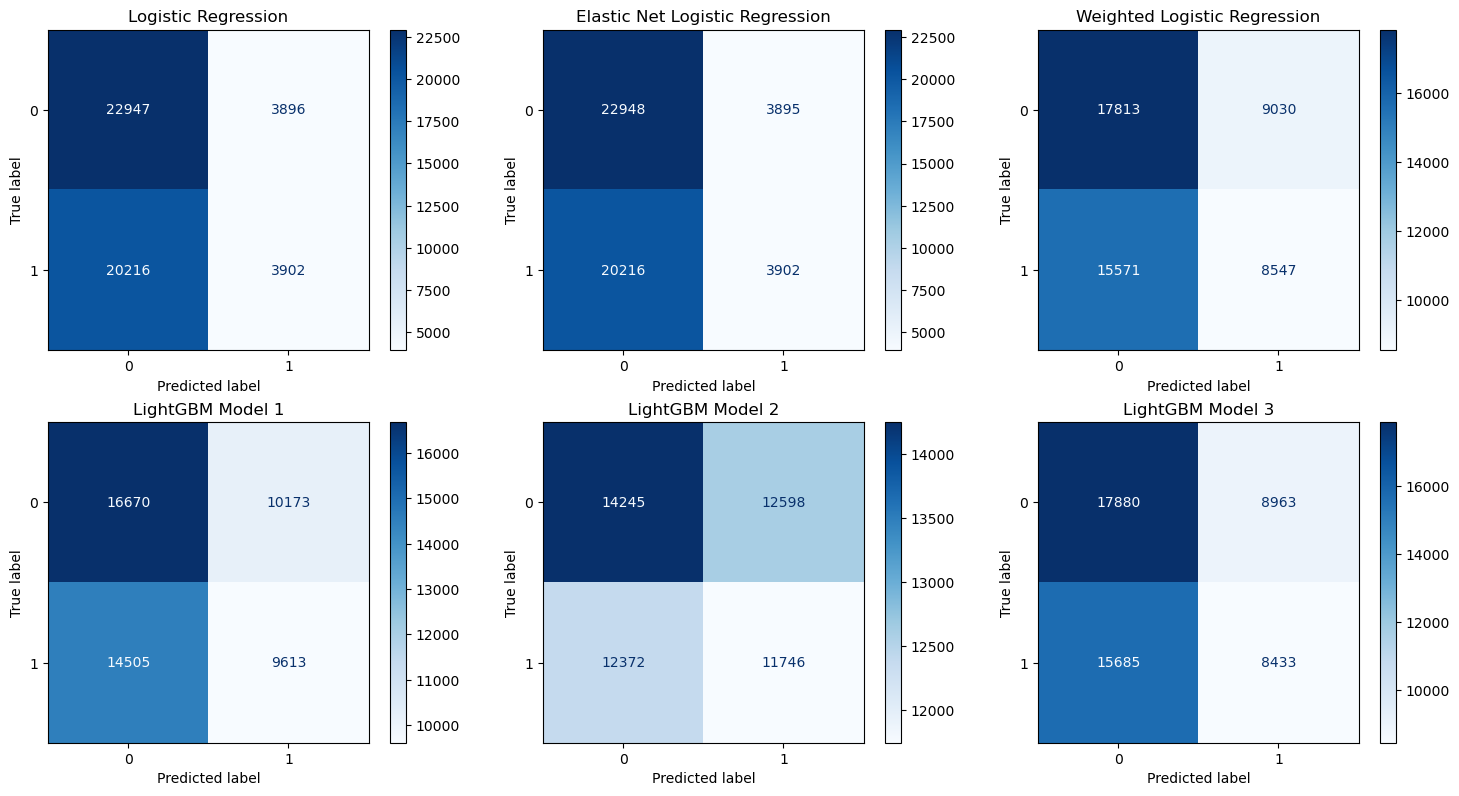

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": log_reg,
    "Elastic Net Logistic Regression": elastic_net,
    "Weighted Logistic Regression": weight_log_reg,
    "LightGBM Model 1": lgb_model1,
    "LightGBM Model 2": lgb_model2,
    "LightGBM Model 3": lgb_model3
}

# Create confusion matrix tables
cm_tables = {}
for name, model in models.items():

    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)  # [[TN, FP], [FN, TP]]
    cm_df = pd.DataFrame(cm,
                         index=["Actual 0", "Actual 1"],
                         columns=["Pred 0", "Pred 1"])
    cm_tables[name] = cm_df
    print(f"\n{name}\n{cm_df}")
    
# Plot confusion matrix for each model
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (name, model) in zip(axes.flat, models.items()):
    y_pred = model.predict(X_val)
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred, ax=ax, cmap="Blues", values_format="d"
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()



NN Baseline
          Pred 0  Pred 1
Actual 0   10103   16740
Actual 1    9057   15061

NN Regularized
          Pred 0  Pred 1
Actual 0   10764   16079
Actual 1    9830   14288

NN Regularized Deep
          Pred 0  Pred 1
Actual 0    8414   18429
Actual 1    7615   16503


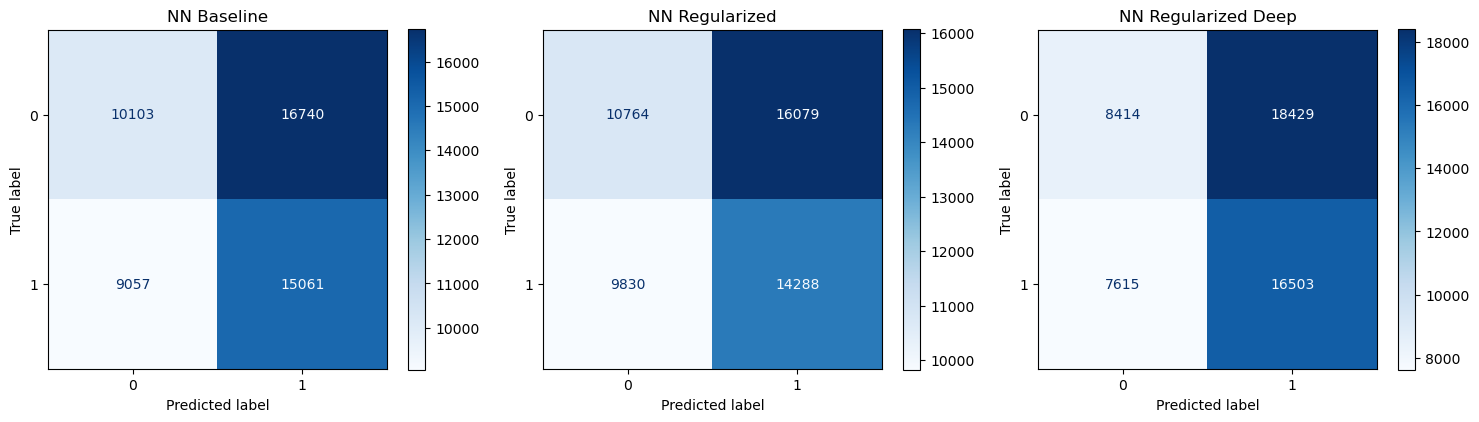

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

nn_models = {
    "NN Baseline": model_base,
    "NN Regularized": model_reg,
    "NN Regularized Deep": model_reg_deep
}

X_nn = X_val_s

# make sure y is 1D
y_true = np.asarray(y_val).ravel()

# Create confusion matrix tables
cm_tables_nn = {}

for name, model in nn_models.items():
    prob = model.predict(X_nn, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)

    cm = confusion_matrix(y_true, pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    )

    cm_tables_nn[name] = cm_df
    print(f"\n{name}\n{cm_df}")

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes.flat, nn_models.items()):
    prob = model.predict(X_nn, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        pred,
        ax=ax,
        cmap="Blues",
        values_format="d"
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import log_loss

def get_model_errors(model, X_train, y_train, X_val, y_val):
    train_probs = model.predict_proba(X_train)[:, 1]
    val_probs = model.predict_proba(X_val)[:, 1]

    train_loss = log_loss(y_train, train_probs)
    val_loss = log_loss(y_val, val_probs)

    return train_loss, val_loss

In [33]:
def get_nn_errors(history):
    train_loss = min(history.history['loss'])
    val_loss = min(history.history['val_loss'])
    return train_loss, val_loss

In [34]:
results = []

# Logistic + LGBM
models = [
    ("LogReg L1", log_reg),
    ("Elastic Net", elastic_net),
    ("Weighted LogReg", weight_log_reg),
    ("LGBM 1", lgb_model1),
    ("LGBM 2", lgb_model2),
    ("LGBM 3", lgb_model3),
]

for name, model in models:
    train_loss, val_loss = get_model_errors(model, X_train, y_train, X_val, y_val)
    results.append((name, train_loss, val_loss))

# Neural Networks
nn_models = [
    ("NN Baseline", history_base),
    ("NN Regularized", history_reg),
    ("NN Deep", history_reg_deep),
]

for name, history in nn_models:
    train_loss, val_loss = get_nn_errors(history)
    results.append((name, train_loss, val_loss))

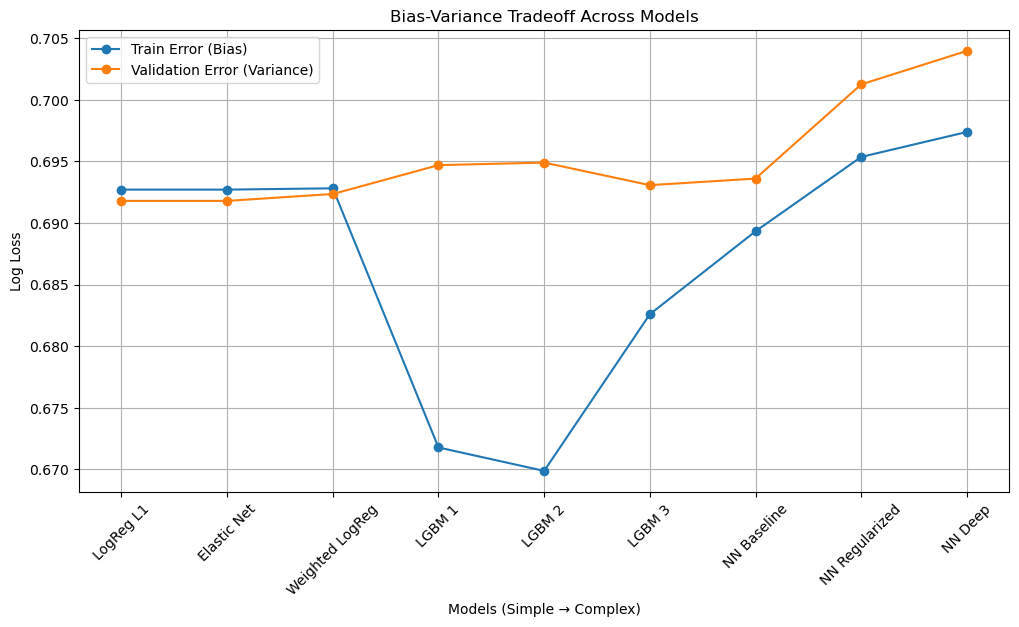

In [35]:
import matplotlib.pyplot as plt

model_names = [r[0] for r in results]
train_errors = [r[1] for r in results]
val_errors = [r[2] for r in results]

plt.figure(figsize=(12,6))

plt.plot(model_names, train_errors, marker='o', label='Train Error (Bias)')
plt.plot(model_names, val_errors, marker='o', label='Validation Error (Variance)')

plt.xticks(rotation=45)
plt.ylabel("Log Loss")
plt.xlabel("Models (Simple → Complex)")
plt.title("Bias-Variance Tradeoff Across Models")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
'''
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("NN Baseline - Test Set:")
evaluate_nn_model(model_base, X_test_s, y_test_nn, name="NN Baseline")

print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("NN Regularized - Test Set:")
evaluate_nn_model(model_reg, X_test_s, y_test_nn, name="NN Regularized")

print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("NN Regularized Deep- Test Set:")
evaluate_nn_model(model_reg_deep, X_test_s, y_test_nn, name="NN Regularized Deep")
'''

In [37]:
# Selected the best model from validation performance and evaluate on test set
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("LightGBM Model 2 - Test Set:")
evaluate(lgb_model2, X_test, y_test)



-----  -----  -----  -----  -----  -----  -----  -----  -----  -----
LightGBM Model 2 - Test Set:
Classification Report:

              precision    recall  f1-score   support

           0       0.55      0.53      0.54     25892
           1       0.48      0.50      0.49     22601

    accuracy                           0.52     48493
   macro avg       0.52      0.52      0.52     48493
weighted avg       0.52      0.52      0.52     48493

F1: 0.5155
ROC-AUC: 0.5215
